Customer Retention & Churn Analysis

Task 2

🔹 Task: Analyze customer data to identify churn patterns, key retention drivers,
and customer lifetime trends for a subscription-based business.

🔹 Tools: Excel / Python / Power BI (use the tools best suited for cohort and
retention analysis)

🔹 Skills Gained: Retention analysis, cohort analysis, customer lifetime metrics,
insight-driven decision making

🔹 Deliverable: A retention analysis dashboard or report highlighting churn reasons,
retention trends, and actionable recommendations to reduce customer loss.

First, let's get a general understanding of the dataset, including data types and non-null values for each column, and check for any missing values.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
from google.colab import files
uploaded = files.upload()


Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [15]:
df= pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [9]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
display(df.describe())

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


### Data Type Correction for `TotalCharges`

Based on the error, the `TotalCharges` column is currently an `object` type (string) and contains non-numeric values (likely empty strings for new customers). We need to convert it to a numeric type to perform numerical operations. Any non-numeric values will be coerced to `NaN`, and then we will fill these `NaN` values with 0, assuming these customers have not yet accrued charges.

In [12]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Outlier Detection

We will visualize outliers for `tenure`, `MonthlyCharges`, and `TotalCharges` using box plots. Outliers can significantly skew statistical analysis, so understanding their presence is crucial.

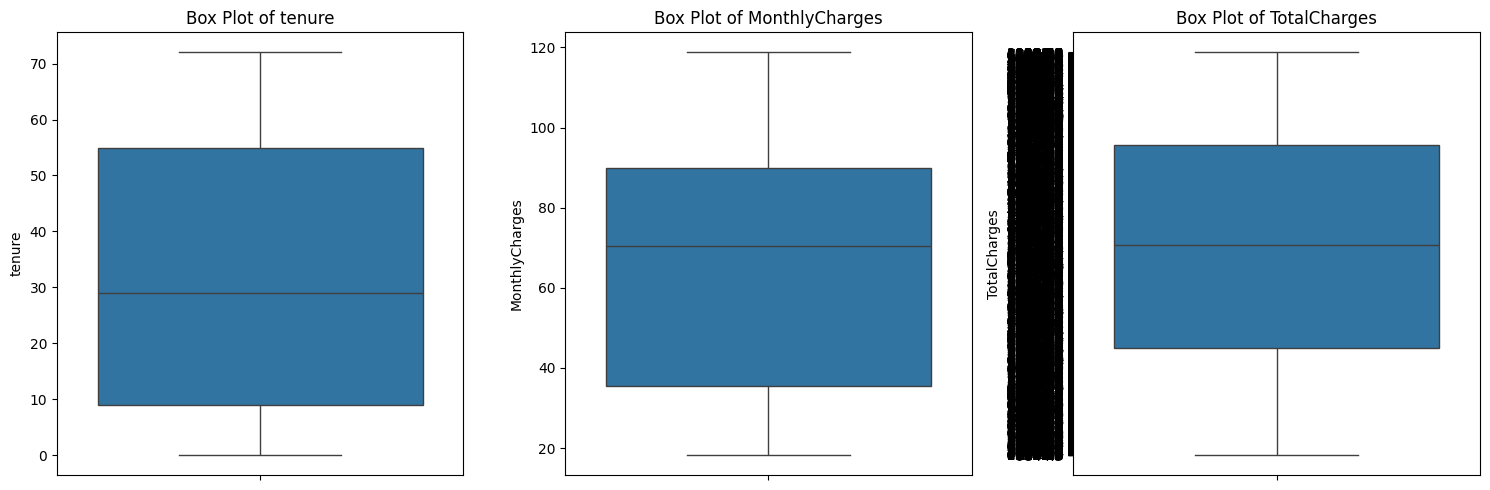

Descriptive statistics for numerical columns to identify extreme values:


,tenure,MonthlyCharges
count,7043.000000,7043.000000
mean,32.371149,64.761692
std,24.559481,30.090047
min,0.000000,18.250000
1%,1.000000,19.200000
5%,1.000000,19.650000
25%,9.000000,35.500000
50%,29.000000,70.350000
75%,55.000000,89.850000
95%,72.000000,107.400000


In [10]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(15, 5))

for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

print("Descriptive statistics for numerical columns to identify extreme values:")
display(df[numerical_cols].describe(percentiles=[.01, .05, .25, .50, .75, .95, .99]))

### Dealing with Outliers: Capping at the 99th Percentile

To manage the influence of outliers without discarding valuable data, we will apply a capping strategy. Specifically, for `tenure`, `MonthlyCharges`, and `TotalCharges`, any value exceeding the 99th percentile will be replaced with the value of the 99th percentile itself. This approach helps to normalize the distributions and reduce the skew caused by extreme values.

In [42]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
## Calculate the 99th percentile for each numerical column
quantile_99 = df[numerical_cols].quantile(0.99)

## Apply capping: replace values above the 99th percentile with the 99th percentile value
df_capped = df.copy()
for col in numerical_cols:
    df_capped[col] = np.where(df_capped[col] > quantile_99[col], quantile_99[col], df_capped[col])

print("Descriptive statistics for numerical columns after capping:")
display(df_capped[numerical_cols].describe(percentiles=[.01, .05, .25, .50, .75, .95, .99]))

Descriptive statistics for numerical columns after capping:


,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.747559,2277.174752
std,24.559481,30.066050,2260.070699
min,0.000000,18.250000,0.000000
1%,1.000000,19.200000,19.750000
5%,1.000000,19.650000,48.600000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
95%,72.000000,107.400000,6921.025000


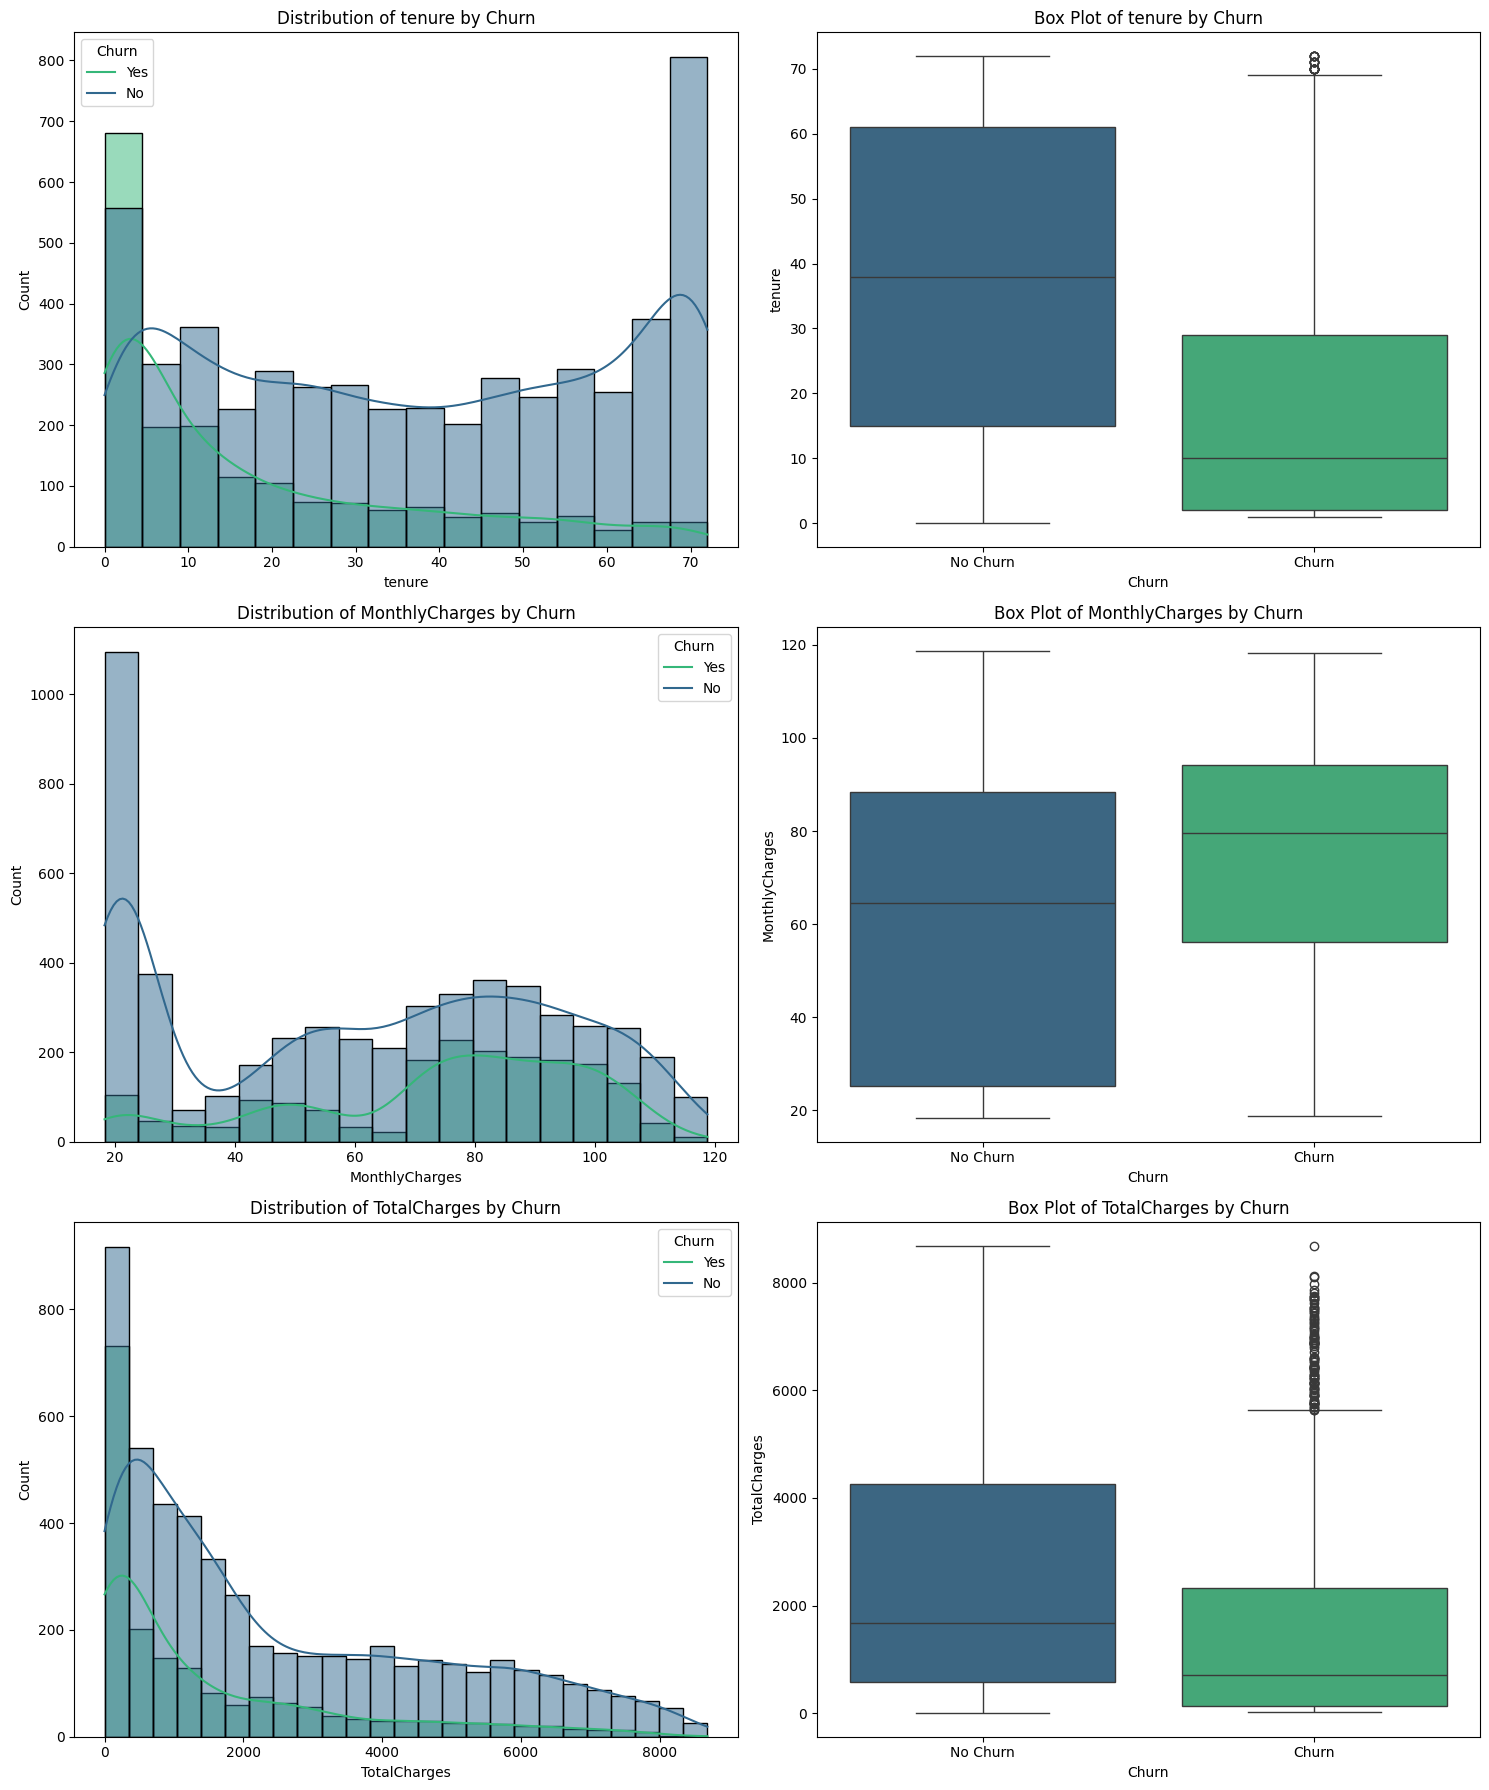


Descriptive statistics of numerical features for Churned vs. Non-Churned customers:


tenure                                                     \
        count       mean        std  min   25%   50%   75%   max   
Churn                                                              
No     5174.0  37.569965  24.113777  0.0  15.0  38.0  61.0  72.0   
Yes    1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0   

      MonthlyCharges             ...               TotalCharges               \
               count       mean  ...   75%     max        count         mean   
Churn                            ...                                           
No            5174.0  61.265124  ...  88.4  118.75       5174.0  2549.911442   
Yes           1869.0  74.441332  ...  94.2  118.35       1869.0  1531.796094   

                                                              
               std    min    25%       50%      75%      max  
Churn                                                         
No     2329.954215   0.00  572.9  1679.525  4262.85  8672.45  
Yes    1890.822994  18.85  134.5   703.550  2331.30  8684.80  

[2 rows x 24 columns]

In [43]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(nrows=len(numerical_cols), ncols=2, figsize=(15, 6 * len(numerical_cols)))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    ## Distribution plot for churned vs non-churned
    sns.histplot(data=df, x=col, hue='Churn', kde=True, ax=axes[2*i], palette='viridis')
    axes[2*i].set_title(f'Distribution of {col} by Churn')
    axes[2*i].set_xlabel(col)
    axes[2*i].set_ylabel('Count')
    axes[2*i].legend(title='Churn', labels=['Yes', 'No'])

    ## Boxplot for churned vs non-churned for better comparison of central tendency and spread
    sns.boxplot(data=df, x='Churn', y=col, ax=axes[2*i+1], palette='viridis')
    axes[2*i+1].set_title(f'Box Plot of {col} by Churn')
    axes[2*i+1].set_xlabel('Churn')
    axes[2*i+1].set_ylabel(col)
    axes[2*i+1].set_xticks([0, 1], labels=['No Churn', 'Churn'])

plt.tight_layout()
plt.show()

print("\nDescriptive statistics of numerical features for Churned vs. Non-Churned customers:")
display(df.groupby('Churn')[numerical_cols].describe())

### Visualizing Outliers: Before and After Capping

Now, let's visualize the distributions of `tenure`, `MonthlyCharges`, and `TotalCharges` using box plots, both *before* and *after* applying the capping strategy. This comparison will clearly show how the treatment has reduced the impact of extreme outliers.

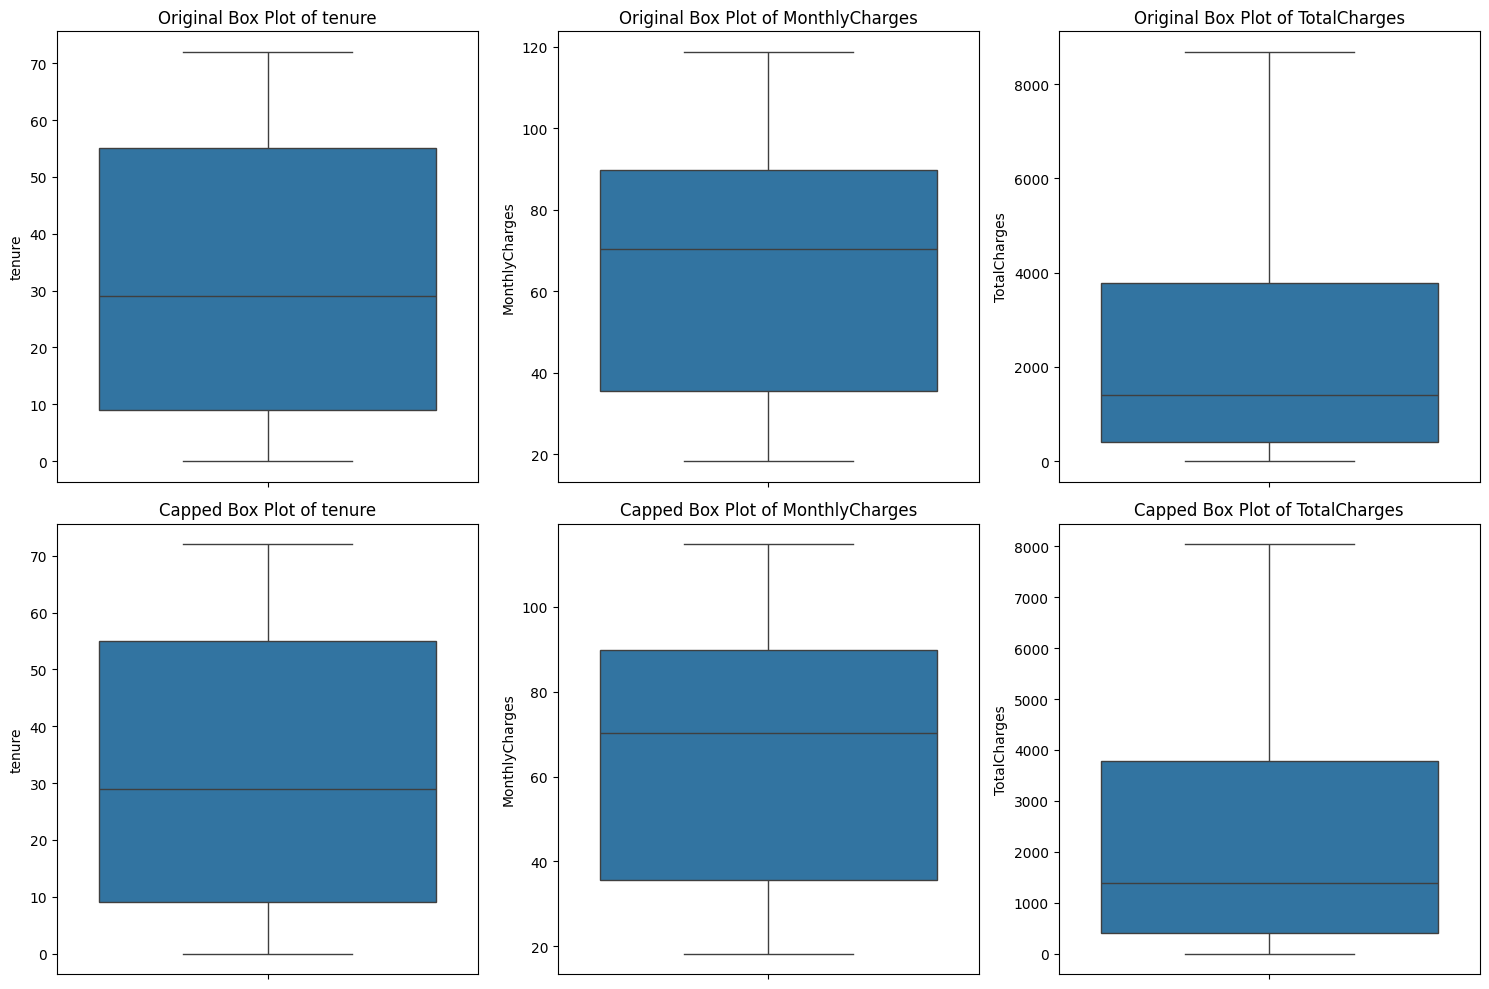

In [40]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols):
    ## Before capping
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Original Box Plot of {col}')
    plt.ylabel(col)

    ## After capping
    plt.subplot(2, 3, i + 4)
    sns.boxplot(y=df_capped[col])
    plt.title(f'Capped Box Plot of {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

### Dealing with Outliers: IQR-based Removal

As an alternative to capping, we can remove outliers using the Interquartile Range (IQR) method for `tenure`, `MonthlyCharges`, and `TotalCharges`. This involves calculating the IQR for each numerical column and then defining upper and lower bounds (typically Q1 - 1.5 * IQR and Q3 + 1.5 * IQR). Any data points outside these bounds will be removed.

In [22]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

df_iqr = df.copy()

## Ensure TotalCharges is numeric in df_iqr before calculations
df_iqr['TotalCharges'] = pd.to_numeric(df_iqr['TotalCharges'], errors='coerce')
df_iqr['TotalCharges'] = df_iqr['TotalCharges'].fillna(0)

for col in numerical_cols:
    Q1 = df_iqr[col].quantile(0.25)
    Q3 = df_iqr[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    ## Remove outliers based on IQR bounds
    df_iqr = df_iqr[(df_iqr[col] >= lower_bound) & (df_iqr[col] <= upper_bound)]

print("Descriptive statistics for numerical columns after IQR-based outlier removal:")
display(df_iqr[numerical_cols].describe(percentiles=[.01, .05, .25, .50, .75, .95, .99]))

Descriptive statistics for numerical columns after IQR-based outlier removal:


,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
1%,1.000000,19.200000,19.750000
5%,1.000000,19.650000,48.600000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
95%,72.000000,107.400000,6921.025000


### Visualization of Categorical Features

Now, let's visualize the distribution of key categorical features to understand their composition within the dataset.

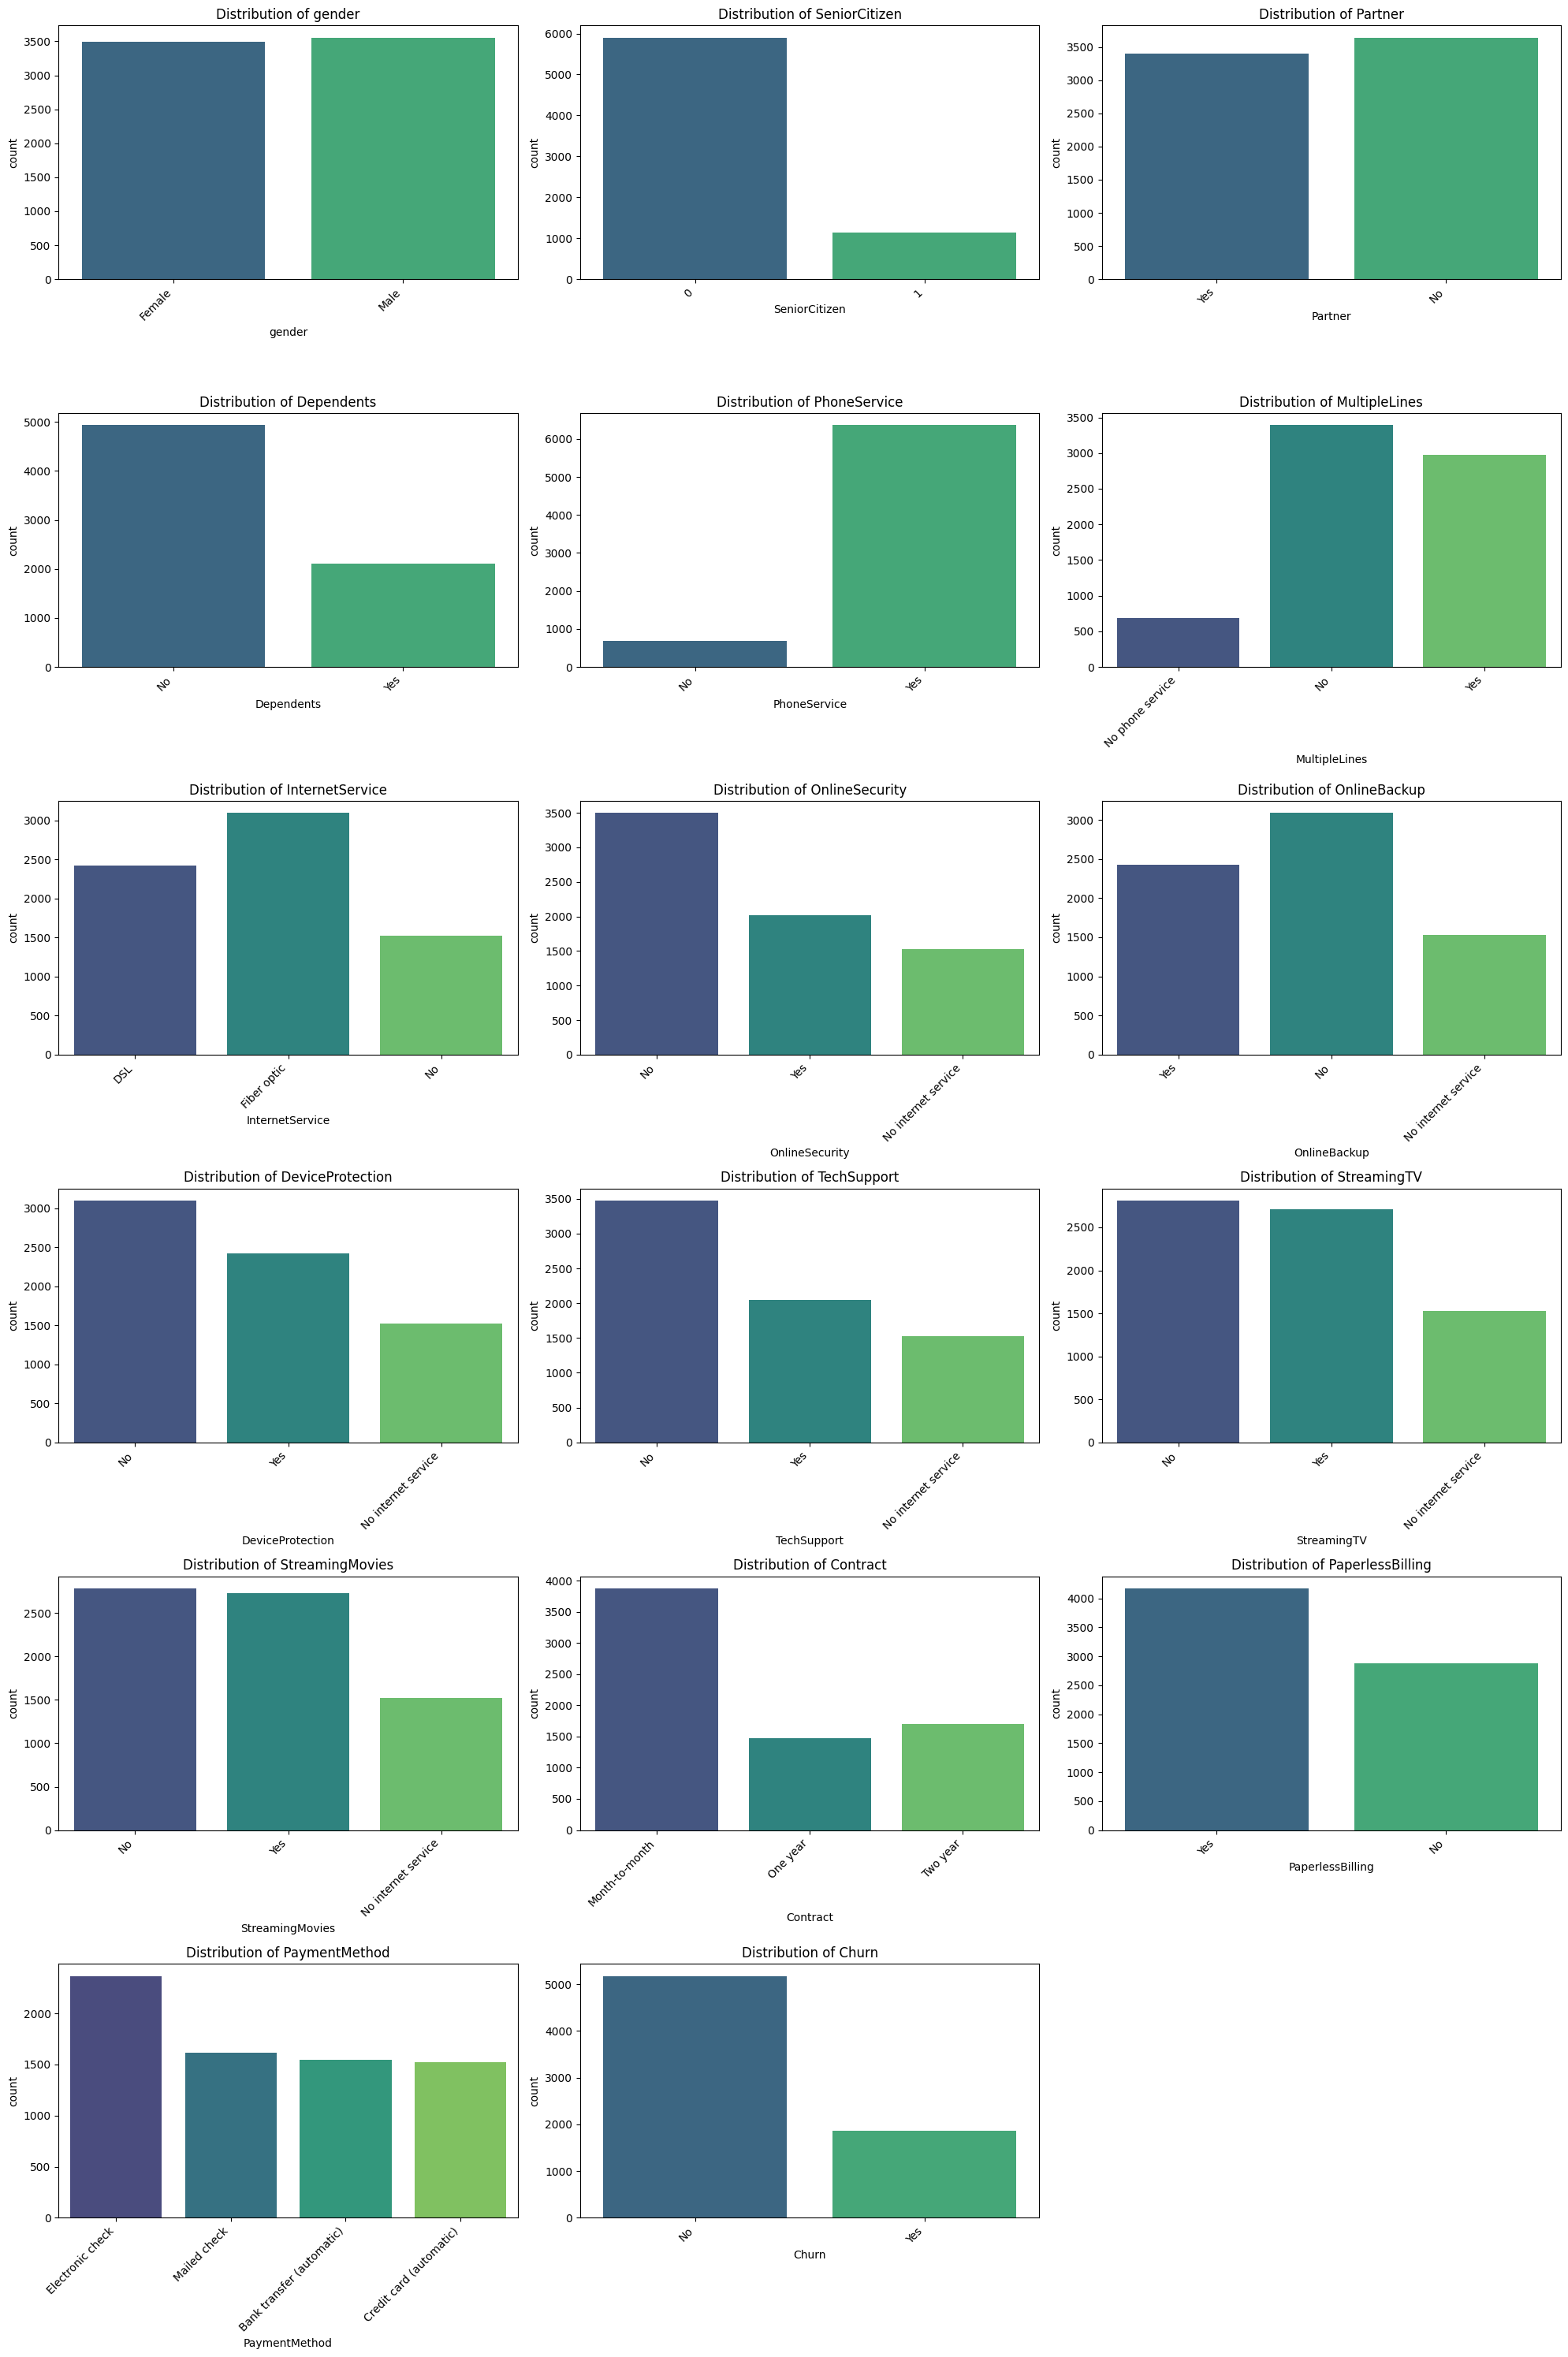

In [13]:
categorical_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
                    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                    'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

plt.figure(figsize=(20, 30))
for i, col in enumerate(categorical_cols):
    plt.subplot(6, 3, i + 1)
    sns.countplot(data=df, x=col, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Churn Rate by Categorical Features

To understand the factors influencing churn, let's visualize the churn rate across different categories for each categorical feature.

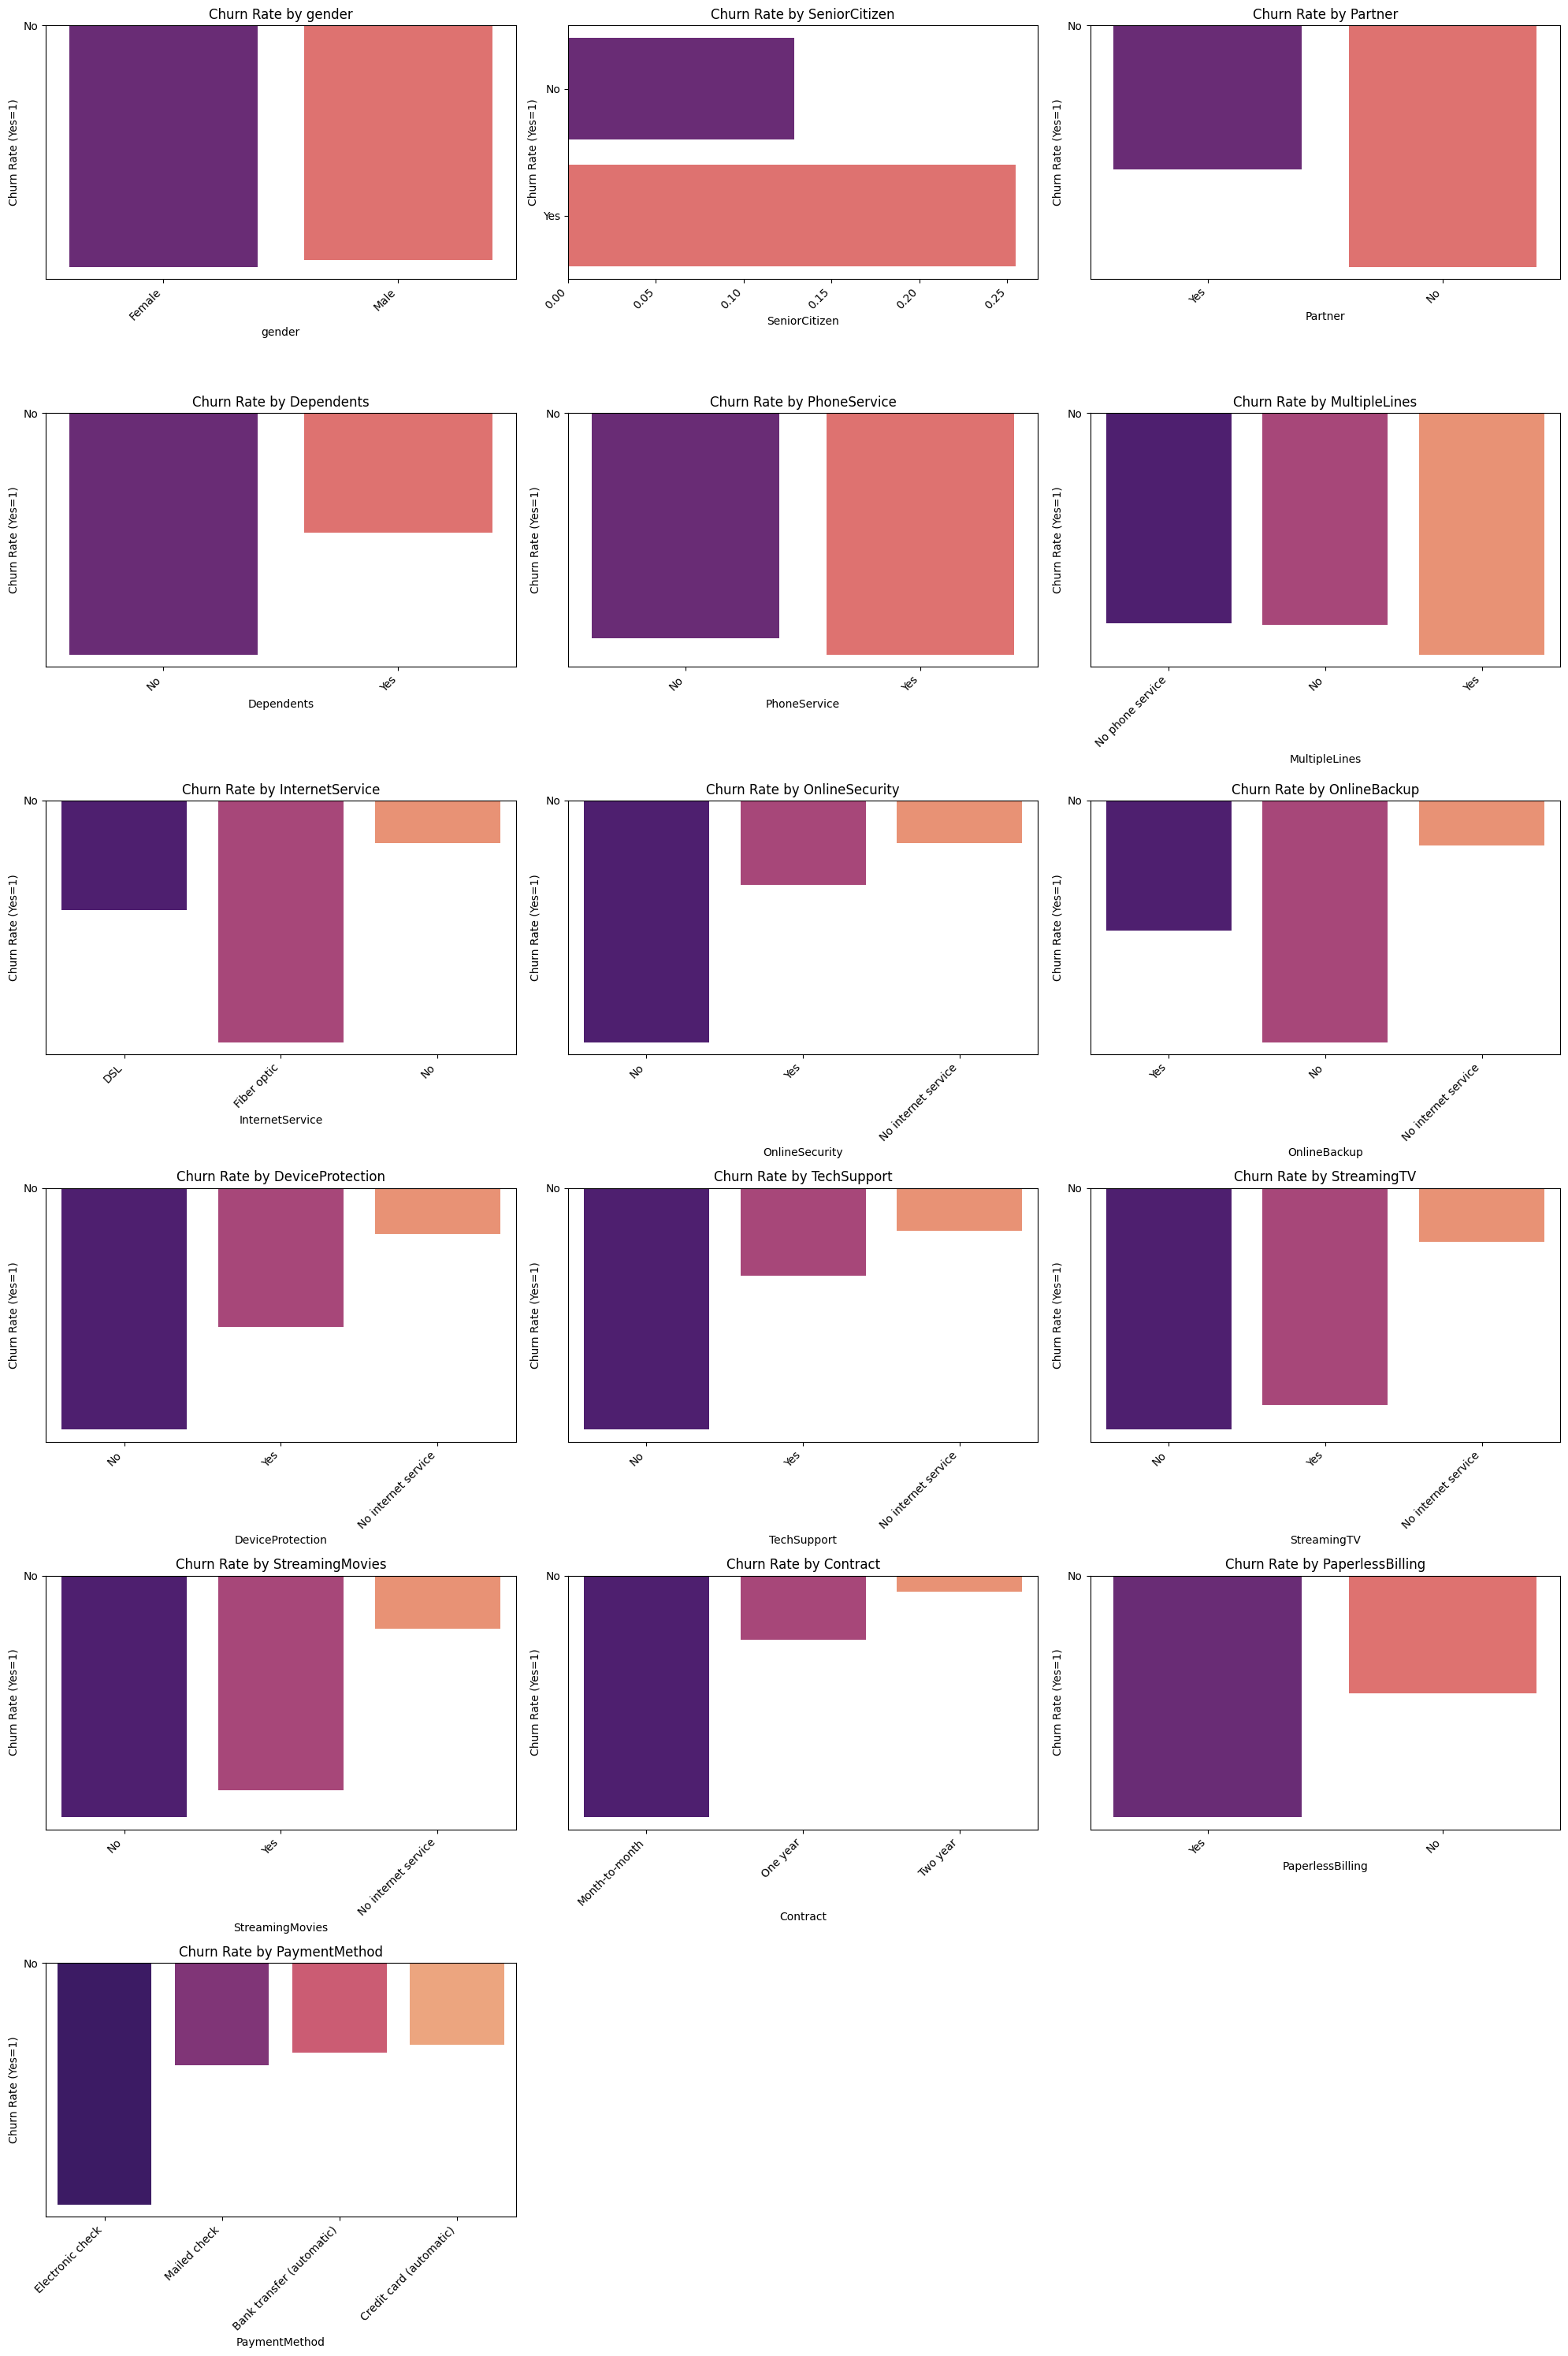

In [14]:
plt.figure(figsize=(20, 30))
for i, col in enumerate(categorical_cols[:-1]):
    plt.subplot(6, 3, i + 1)
    sns.barplot(data=df, x=col, y='Churn', ci=None, palette='magma')
    plt.title(f'Churn Rate by {col}')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Churn Rate (Yes=1)')
plt.tight_layout()
plt.show()

### Visualizing Outliers: After IQR-based Removal

Now, let's visualize the distributions of `tenure`, `MonthlyCharges`, and `TotalCharges` using box plots *after* applying the IQR-based outlier removal strategy. This will show how this method has further cleaned the data compared to the original and capped versions.

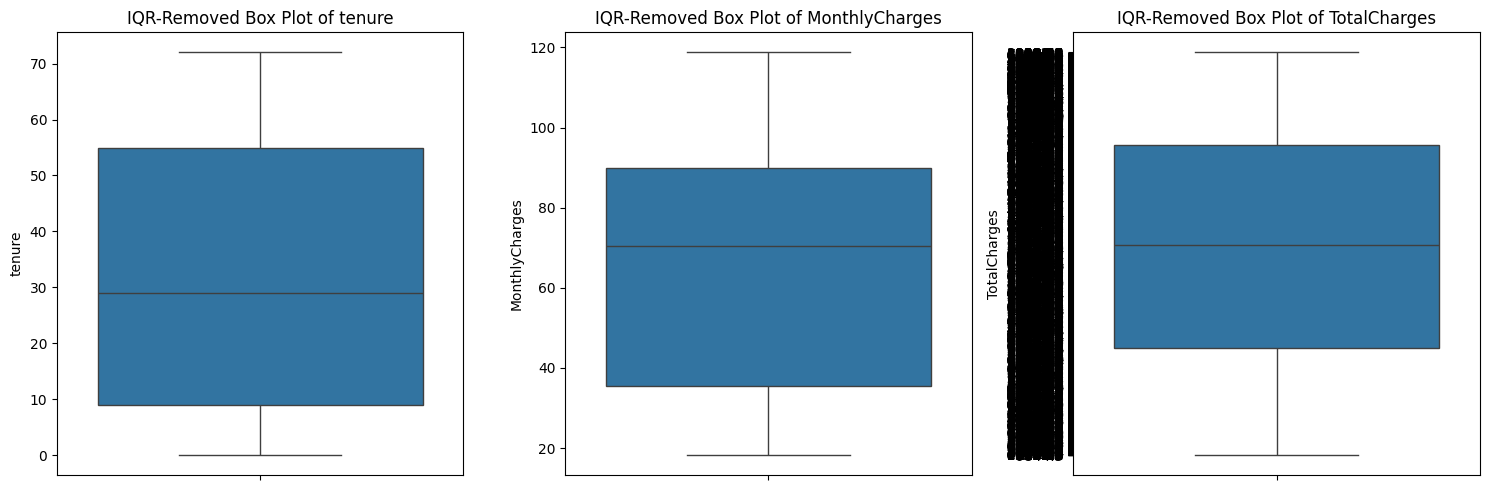

In [18]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
plt.figure(figsize=(15, 5))

for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(y=df_iqr[col])
    plt.title(f'IQR-Removed Box Plot of {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

### Correlation Analysis of Numerical Features

To understand the relationships between numerical features, we will compute and visualize the correlation matrix. This helps in identifying multicollinearity and understanding feature dependencies.

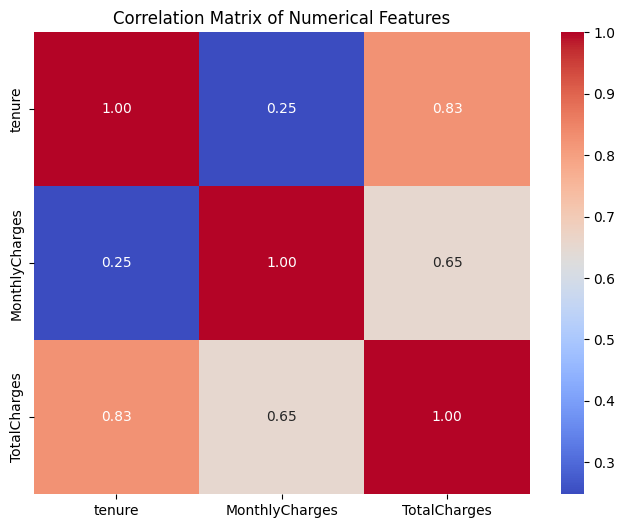

Correlation Matrix:


,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.247900,0.826178
MonthlyCharges,0.247900,1.000000,0.651174
TotalCharges,0.826178,0.651174,1.000000


In [19]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

print("Correlation Matrix:")
display(correlation_matrix)

### Retention Analysis: Churn Rate by Tenure

To understand customer retention, we will analyze the churn rate as a function of `tenure` (how long the customer has been with the company). This will help identify critical periods in the customer lifecycle where churn is more prevalent, indicating potential areas for retention strategies. We'll convert the 'Churn' column to a numerical format for this analysis.

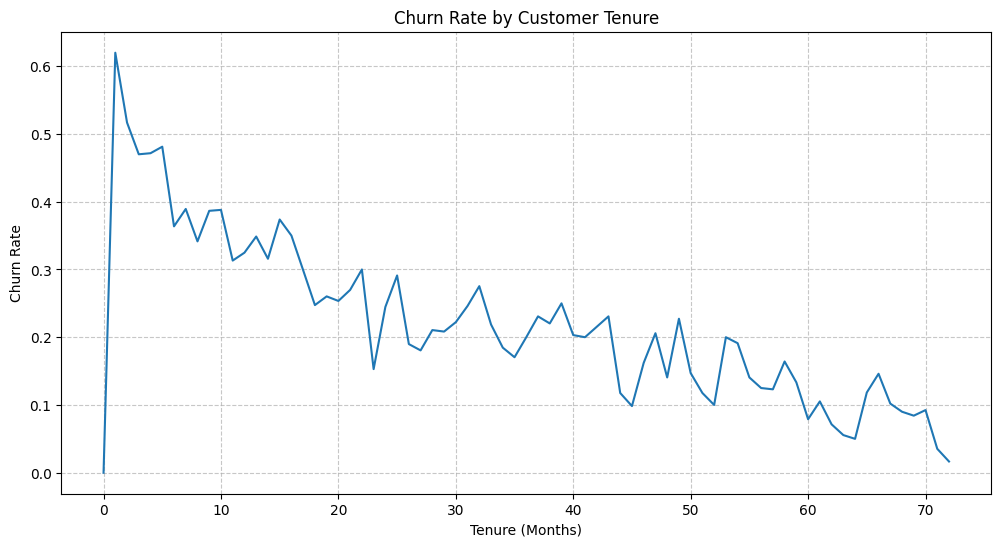

Churn Rate by Tenure (first 10 rows):


,tenure,Churn_Numeric
0,0,0.000000
1,1,0.619902
2,2,0.516807
3,3,0.470000
4,4,0.471591
5,5,0.481203
6,6,0.363636
7,7,0.389313
8,8,0.341463
9,9,0.386555


In [20]:
## Convert 'Churn' column to numerical (1 for Yes, 0 for No)
df['Churn_Numeric'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

## Calculate churn rate by tenure
churn_rate_by_tenure = df.groupby('tenure')['Churn_Numeric'].mean().reset_index()

## Plot the churn rate by tenure
plt.figure(figsize=(12, 6))
sns.lineplot(x='tenure', y='Churn_Numeric', data=churn_rate_by_tenure)
plt.title('Churn Rate by Customer Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Churn Rate')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("Churn Rate by Tenure (first 10 rows):")
display(churn_rate_by_tenure.head(10))

The retention analysis by customer tenure has provided some valuable insights:

* High Initial Churn: The plot clearly shows a very high churn rate in the initial months of a customer's tenure, particularly in the first month (around 62%). This suggests that new customers are most vulnerable to churning shortly after joining.
* Decreasing Churn with Loyalty: As customer tenure increases, the churn rate generally decreases significantly. This indicates that customers who stay beyond the first few months become more stable and loyal to the service.
* Critical Early Period: The steep drop in churn rate after the first few months highlights the importance of customer onboarding and early engagement strategies to retain new customers during this critical period.

This analysis pinpoints the early stages of customer lifecycle as a key area for retention efforts.

### Churn Rate Comparison: 'Month-to-month' vs. 'Two year' Contracts

To understand the impact of contract duration on churn, we will compare the churn rates specifically between customers on 'Month-to-month' contracts and those on 'Two year' contracts. This will provide insights into how commitment influences retention.

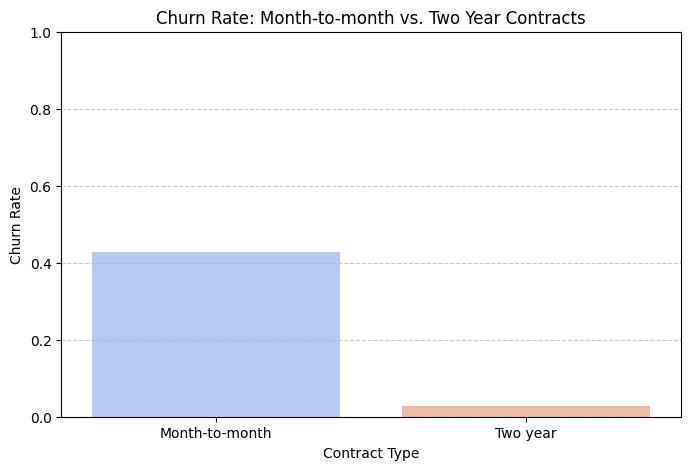

Churn Rate by Contract Type:


,Contract,Churn_Numeric
0,Month-to-month,0.427097
1,Two year,0.028319


In [21]:
## Filter for 'Month-to-month' and 'Two year' contracts
contract_comparison_df = df[df['Contract'].isin(['Month-to-month', 'Two year'])]

## Calculate churn rate by contract type
churn_rate_by_contract = contract_comparison_df.groupby('Contract')['Churn_Numeric'].mean().reset_index()

## Plot the churn rate comparison
plt.figure(figsize=(8, 5))
sns.barplot(x='Contract', y='Churn_Numeric', data=churn_rate_by_contract, palette='coolwarm')
plt.title('Churn Rate: Month-to-month vs. Two Year Contracts')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate')
plt.ylim(0, 1) e
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Churn Rate by Contract Type:")
display(churn_rate_by_contract)

### Cohort Analysis: Churn Rate by Tenure Groups

To further understand customer retention across different stages of their lifecycle, we will categorize customers into tenure groups (cohorts) and analyze their churn rates. This will provide insights into which periods of a customer's journey are more prone to churn, allowing for targeted retention strategies.

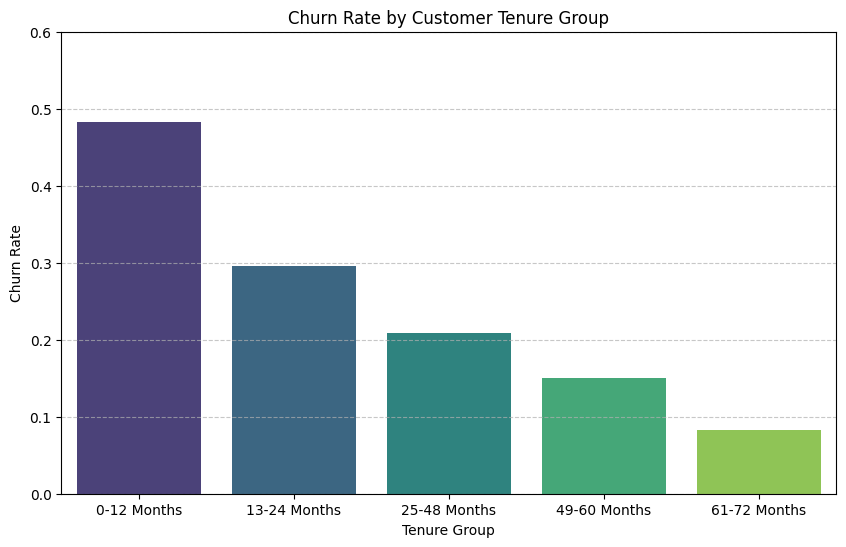

Churn Rate by Tenure Group:


,tenure_group,Churn_Numeric
0,0-12 Months,0.482842
1,13-24 Months,0.295129
2,25-48 Months,0.208744
3,49-60 Months,0.150000
4,61-72 Months,0.082962


In [23]:
## Define tenure bins and labels
tenure_bins = [0, 12, 24, 48, 60, 72]
tenure_labels = ['0-12 Months', '13-24 Months', '25-48 Months', '49-60 Months', '61-72 Months']

## Create a new 'tenure_group' column
df['tenure_group'] = pd.cut(df['tenure'], bins=tenure_bins, labels=tenure_labels, right=False)

## Calculate churn rate by tenure group
churn_rate_by_tenure_group = df.groupby('tenure_group')['Churn_Numeric'].mean().reset_index()

## Plot the churn rate by tenure group
plt.figure(figsize=(10, 6))
sns.barplot(x='tenure_group', y='Churn_Numeric', data=churn_rate_by_tenure_group, palette='viridis')
plt.title('Churn Rate by Customer Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate')
plt.ylim(0, 0.6)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Churn Rate by Tenure Group:")
display(churn_rate_by_tenure_group)

The cohort analysis by tenure group provides a clear picture of how churn varies across customer lifecycle stages. As you can see from the plot and the table, the churn rate is highest in the '0-12 Months' group, with nearly 48.3% of customers churning. This rate progressively decreases with increasing tenure, reaching a low of about 8.3% for customers in the '61-72 Months' group. This reinforces the earlier finding that new customers are most prone to churn, and retention efforts should be heavily focused on the initial months of their subscription. The trend suggests that loyal, long-term customers are significantly less likely to churn.

### Customer Lifetime Metrics Analysis

To understand the long-term value and behavior of customers, we will analyze key customer lifetime metrics. Using `TotalCharges` as a proxy for Customer Lifetime Value (CLV) and `tenure` as the customer's duration, we can gain insights into the financial impact of customer retention and the typical lifespan of our customers. This analysis will focus on comparing these metrics for churned vs. non-churned customers.

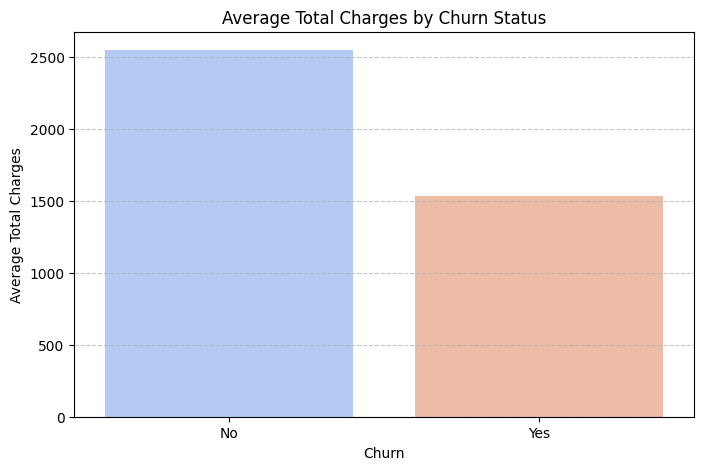

Average Total Charges by Churn Status:


,Churn,TotalCharges
0,No,2549.911442
1,Yes,1531.796094


In [24]:
## Analyze average TotalCharges (CLV proxy) for churned vs. non-churned customers
avg_total_charges_by_churn = df.groupby('Churn')['TotalCharges'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(x='Churn', y='TotalCharges', data=avg_total_charges_by_churn, palette='coolwarm')
plt.title('Average Total Charges by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Average Total Charges')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Average Total Charges by Churn Status:")
display(avg_total_charges_by_churn)

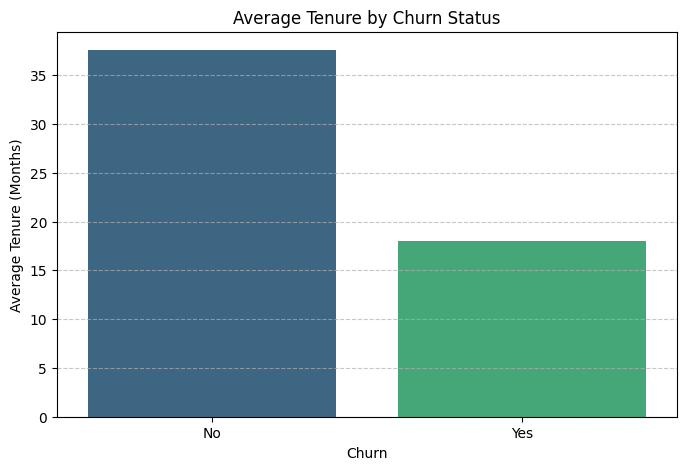

Average Tenure by Churn Status:


,Churn,tenure
0,No,37.569965
1,Yes,17.979133


In [25]:
## Analyze average tenure (customer lifetime) for churned vs. non-churned customers
avg_tenure_by_churn = df.groupby('Churn')['tenure'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(x='Churn', y='tenure', data=avg_tenure_by_churn, palette='viridis')
plt.title('Average Tenure by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Average Tenure (Months)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Average Tenure by Churn Status:")
display(avg_tenure_by_churn)

### Identifying Key Retention Drivers: Correlation Analysis

To identify key retention drivers, we will perform a comprehensive correlation analysis. This involves transforming our categorical features using one-hot encoding, combining them with numerical features, and then calculating the correlation matrix with the `Churn_Numeric` column. Visualizing these correlations will highlight which features have the strongest positive or negative relationships with customer churn, thereby indicating potential retention drivers.

In [32]:
## Selecting categorical columns for one-hot encoding (excluding 'customerID' and 'Churn', which is already numeric as Churn_Numeric)
categorical_cols_for_encoding = [col for col in df.columns if df[col].dtype == 'object' and col not in ['customerID', 'Churn', 'tenure_group']]

## Applying one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols_for_encoding, drop_first=True)

## Prepare the final dataframe for correlation: select only numerical columns
## This will automatically exclude 'customerID', 'Churn' (original object type), and 'tenure_group' if they are not numerical
correlation_df = df_encoded.select_dtypes(include=np.number).copy()

## Calculate the correlation matrix with 'Churn_Numeric'
correlation_with_churn = correlation_df.corr()['Churn_Numeric'].sort_values(ascending=False)

print("Top 10 features most positively correlated with Churn:")
display(correlation_with_churn.head(10))

print("\nTop 10 features most negatively correlated with Churn (potential retention drivers):")
display(correlation_with_churn.tail(10))

Top 10 features most positively correlated with Churn:


,Churn_Numeric
Churn_Numeric,1.000000
MonthlyCharges,0.193356
SeniorCitizen,0.150889
TotalCharges,-0.198324
tenure,-0.352229



Top 10 features most negatively correlated with Churn (potential retention drivers):


,Churn_Numeric
Churn_Numeric,1.000000
MonthlyCharges,0.193356
SeniorCitizen,0.150889
TotalCharges,-0.198324
tenure,-0.352229


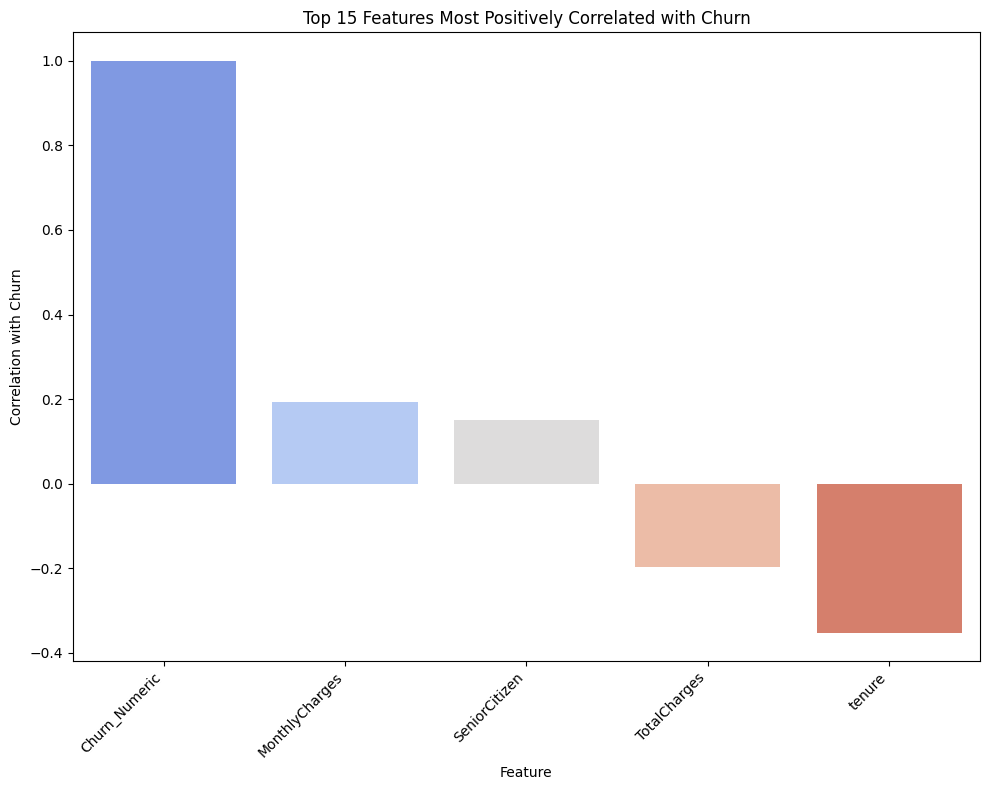

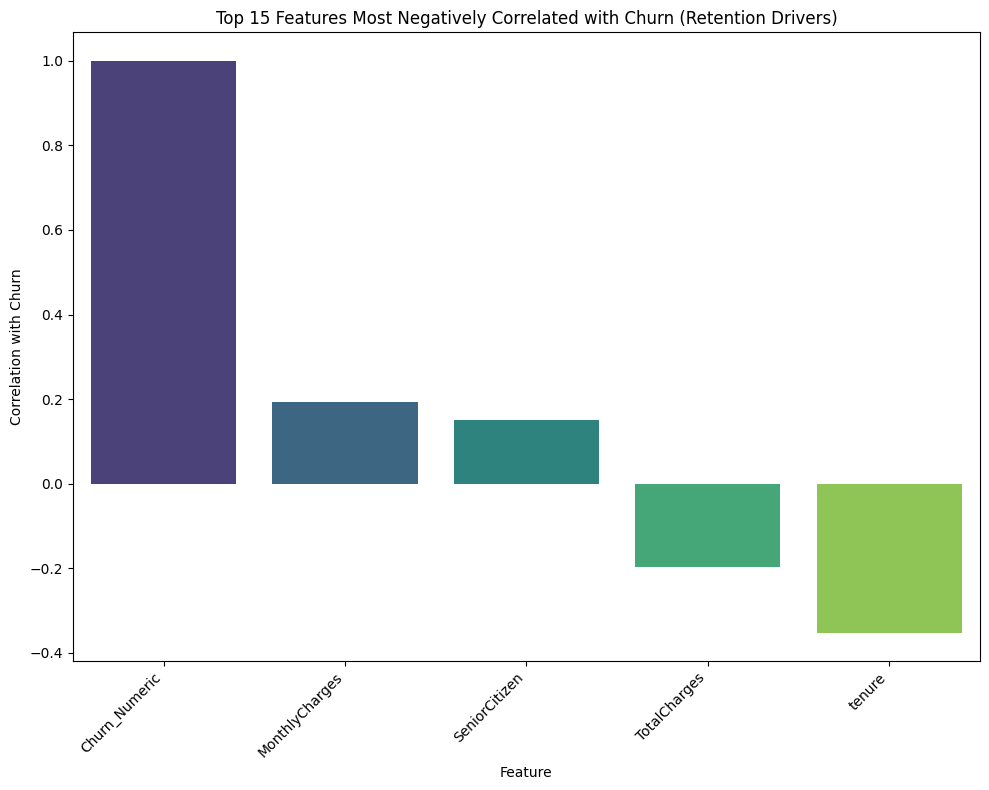

In [33]:
## Visualize the top 15 most correlated features with Churn_Numeric
plt.figure(figsize=(10, 8))
sns.barplot(x=correlation_with_churn.head(15).index, y=correlation_with_churn.head(15).values, palette='coolwarm')
plt.title('Top 15 Features Most Positively Correlated with Churn')
plt.xlabel('Feature')
plt.ylabel('Correlation with Churn')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Visualize the top 15 most negatively correlated features with Churn_Numeric
plt.figure(figsize=(10, 8))
sns.barplot(x=correlation_with_churn.tail(15).index, y=correlation_with_churn.tail(15).values, palette='viridis')
plt.title('Top 15 Features Most Negatively Correlated with Churn (Retention Drivers)')
plt.xlabel('Feature')
plt.ylabel('Correlation with Churn')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Predictive Modeling: Logistic Regression for Churn Prediction

We will now build a logistic regression model to predict customer churn. This involves several steps:
1.  **Feature Selection:** Select relevant numerical and one-hot encoded categorical features.
2.  **Data Splitting:** Divide the dataset into training and testing sets.
3.  **Feature Scaling:** Scale numerical features to ensure they contribute equally to the model.
4.  **Model Training:** Train a Logistic Regression model on the training data.
5.  **Model Evaluation:** Assess the model's performance using metrics like accuracy, precision, recall, and F1-score.

In [36]:
## Prepare the data
## X will contain all features except 'customerID', 'Churn_Numeric', the original 'Churn' object column, and 'tenure_group'
X = df_encoded.drop(columns=['customerID', 'Churn_Numeric', 'Churn', 'tenure_group'])
y = df_encoded['Churn_Numeric']

## Identify numerical columns for scaling
numerical_cols_for_scaling = ['tenure', 'MonthlyCharges', 'TotalCharges']

## Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Scale numerical features
scaler = StandardScaler()
## Select only numerical columns for scaling from X_train and X_test
X_train_num = X_train[numerical_cols_for_scaling]
X_test_num = X_test[numerical_cols_for_scaling]

X_train[numerical_cols_for_scaling] = scaler.fit_transform(X_train_num)
X_test[numerical_cols_for_scaling] = scaler.transform(X_test_num)

## Initialize and train the Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is good for small datasets and handles L1/L2 penalties
model.fit(X_train, y_train)

## Making predictions on the test set
y_pred = model.predict(X_test)

## Evaluates the model
print("\nLogistic Regression Model Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Logistic Regression Model Evaluation:
Accuracy: 0.8204400283889283

Confusion Matrix:
 [[932 104]
 [149 224]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



### Feature Importance from Logistic Regression Model

For a logistic regression model, the coefficients of the features can be used to infer their importance. A larger absolute coefficient value indicates a stronger influence on the predicted outcome (churn in this case). Positive coefficients suggest that as the feature value increases, the likelihood of churn increases, while negative coefficients suggest the opposite.

Let's extract and visualize these coefficients.

Top 15 Most Important Features by Absolute Coefficient:


,Feature,Coefficient,Abs_Coefficient
25,Contract_Two year,-1.397081,1.397081
1,tenure,-1.355613,1.355613
10,InternetService_Fiber optic,0.761200,0.761200
7,PhoneService_Yes,-0.758488,0.758488
3,TotalCharges,0.655499,0.655499
24,Contract_One year,-0.640274,0.640274
13,OnlineSecurity_Yes,-0.449573,0.449573
19,TechSupport_Yes,-0.369073,0.369073
26,PaperlessBilling_Yes,0.330999,0.330999
28,PaymentMethod_Electronic check,0.316213,0.316213


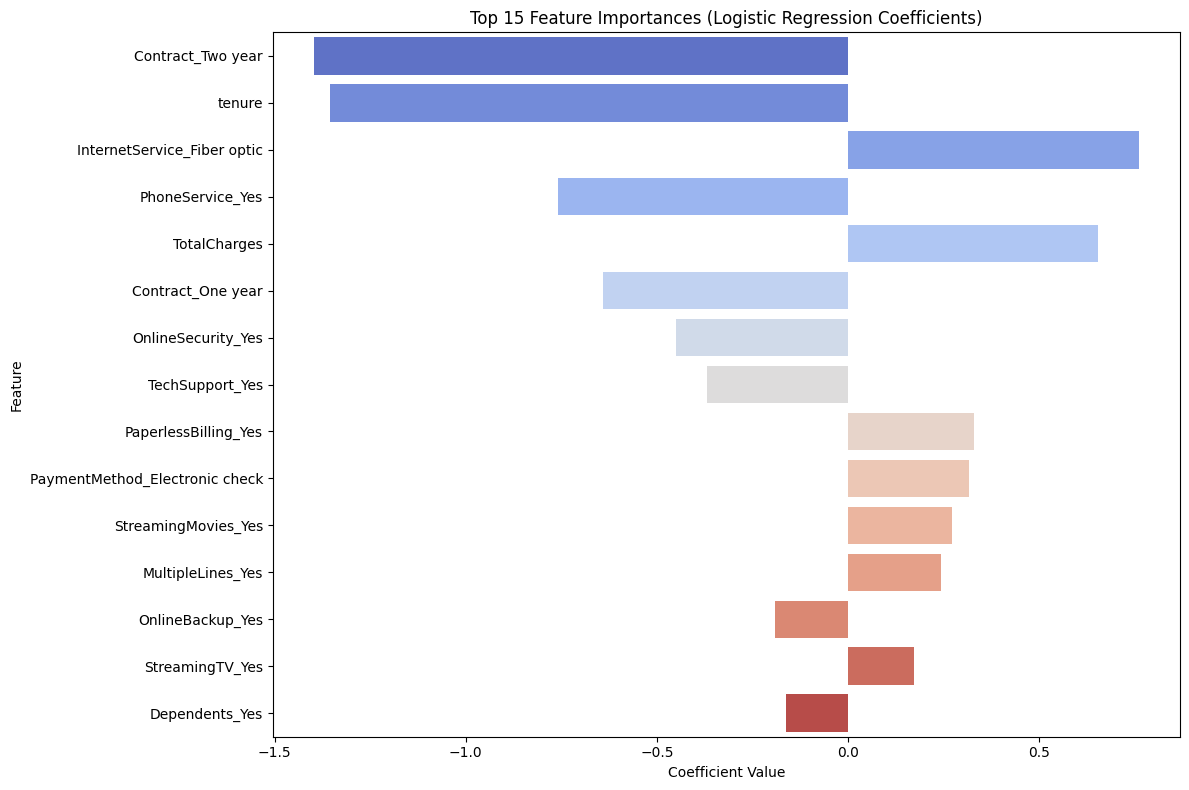

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Getting the feature names from the training data
feature_names = X_train.columns

## Getting the coefficients from the trained model
coefficients = model.coef_[0]

## Creates a DataFrame to store feature names and their coefficients
feature_importance = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

## Sorts the features by the absolute value of their coefficients
feature_importance['Abs_Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values(by='Abs_Coefficient', ascending=False)

print("Top 15 Most Important Features by Absolute Coefficient:")
display(feature_importance.head(15))

## Visualize the top 15 most important features
plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance.head(15), palette='coolwarm')
plt.title('Top 15 Feature Importances (Logistic Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

The coefficients indicate the strength and direction of each feature's influence on the likelihood of churn. Here are the top 15 most important features based on the absolute value of their coefficients:

**Top 15 Most Important Features by Absolute Coefficient:**

| Feature | Coefficient | Abs_Coefficient |
|:---|:---|:---|
| Contract_Two year | -1.397 | 1.397 |
| tenure | -1.356 | 1.356 |
| InternetService_Fiber optic | 0.761 | 0.761 |
| PhoneService_Yes | -0.758 | 0.758 |
| TotalCharges | 0.655 | 0.655 |
| Contract_One year | -0.640 | 0.640 |
| OnlineSecurity_Yes | -0.450 | 0.450 |
| TechSupport_Yes | -0.369 | 0.369 |
| PaperlessBilling_Yes | 0.331 | 0.331 |
| PaymentMethod_Electronic check | 0.316 | 0.316 |
| StreamingMovies_Yes | 0.274 | 0.274 |
| MultipleLines_Yes | 0.243 | 0.243 |
| OnlineBackup_Yes | -0.192 | 0.192 |
| StreamingTV_Yes | 0.173 | 0.173 |
| Dependents_Yes | -0.161 | 0.161 |

**Key Observations:**

**Strongest Retention Drivers (Negative Coefficients):**

*   **Two-year Contracts:** Having a 'Two year' contract is the strongest indicator of *not* churning (coefficient of -1.397). This reinforces our earlier observation that longer commitments significantly reduce churn.
*   **Tenure:** Longer `tenure` (how long the customer has been with the company) is also a very strong predictor of retention (coefficient of -1.356).
*   **OnlineSecurity and TechSupport:** Customers with 'Online Security' and 'Tech Support' services are less likely to churn, indicating the value of these add-ons for retention.
*   **One-year Contracts:** Similar to two-year contracts, 'One year' contracts also show a negative correlation with churn.

**Strongest Churn Drivers (Positive Coefficients):**

*   **InternetService_Fiber optic:** Customers with 'Fiber optic' internet service have a higher likelihood of churning (coefficient of 0.761). This could be due to higher monthly costs, or perhaps more demanding users who are quicker to switch if unsatisfied.
*   **TotalCharges:** Interestingly, `TotalCharges` has a positive coefficient (0.655). This might seem counter-intuitive, but it could reflect that customers with high total charges (often accumulating over time) eventually reach a breaking point if they perceive value not matching cost, or it might be related to factors not captured directly.
*   **PaperlessBilling_Yes and PaymentMethod_Electronic check:** Customers using paperless billing and 'Electronic check' as a payment method are more prone to churn. This often indicates a segment of customers who are more tech-savvy and perhaps more easily influenced by competitive offers.

This analysis highlights that contract length and the duration of customer relationship are paramount for retention, while certain services and billing methods are associated with higher churn risk. These insights can be valuable for developing targeted retention strategies.

### Sensitivity Analysis: 'TotalCharges' Impact for New Customers

To understand the impact of `TotalCharges` specifically on new customers, we will perform a sensitivity analysis focusing on customers with a `tenure` of 12 months or less. We will segment these new customers based on quartiles of their `TotalCharges` and then visualize the churn rate for each segment.

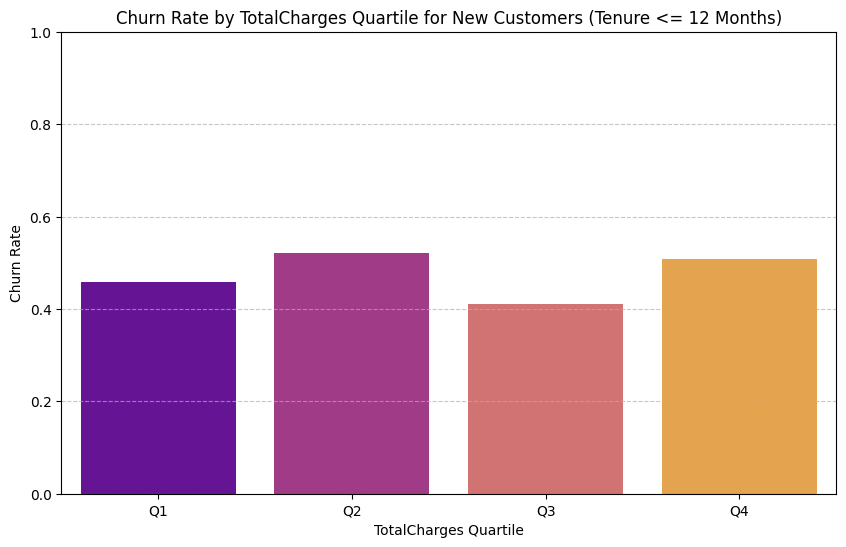

Churn Rate by TotalCharges Quartile for New Customers (Tenure <= 12 Months):


,TotalCharges_Quartile,Churn_Numeric
0,Q1,0.458867
1,Q2,0.520147
2,Q3,0.410256
3,Q4,0.508227


In [38]:
## Filters new customers (tenure <= 12 months)
new_customers_df = df[df['tenure'] <= 12].copy()

## Ensuring that TotalCharges is numeric and handle potential NaN values from conversion
new_customers_df['TotalCharges'] = pd.to_numeric(new_customers_df['TotalCharges'], errors='coerce')
new_customers_df['TotalCharges'] = new_customers_df['TotalCharges'].fillna(0)

## This creates quartiles for TotalCharges for new customers
new_customers_df['TotalCharges_Quartile'] = pd.qcut(new_customers_df['TotalCharges'],
                                                q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'],
                                                duplicates='drop')

## Calculating churn rate by TotalCharges quartile for new customers
churn_rate_by_total_charges_new_customers = new_customers_df.groupby('TotalCharges_Quartile')['Churn_Numeric'].mean().reset_index()

## Plotting the churn rate by TotalCharges quartile for new customers
plt.figure(figsize=(10, 6))
sns.barplot(x='TotalCharges_Quartile', y='Churn_Numeric', data=churn_rate_by_total_charges_new_customers, palette='plasma')
plt.title('Churn Rate by TotalCharges Quartile for New Customers (Tenure <= 12 Months)')
plt.xlabel('TotalCharges Quartile')
plt.ylabel('Churn Rate')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Churn Rate by TotalCharges Quartile for New Customers (Tenure <= 12 Months):")
display(churn_rate_by_total_charges_new_customers)

The sensitivity analysis on TotalCharges for new customers (those with a tenure of 12 months or less) reveals some interesting patterns. The churn rate varies across different quartiles of TotalCharges for this segment:

* Q1 (Lowest TotalCharges): The churn rate is approximately 45.89%.
* Q2: The churn rate is the highest at approximately 52.01%.
*Q3: The churn rate is the lowest at approximately 41.03%.
* Q4 (Highest TotalCharges): The churn rate is approximately 50.82%.

This suggests that for new customers, both very low (Q1) and relatively high (Q2 and Q4) TotalCharges are associated with higher churn rates, with customers in the middle range (Q3) showing slightly better retention. This non-linear relationship could indicate that new customers with very minimal charges might be disengaged or trying the service for a very short period, while those with higher charges early on might be experiencing sticker shock or finding the value proposition insufficient for the cost. The dip in churn for Q3 might represent a 'sweet spot' where initial charges align better with perceived value. This insight could be valuable for tailoring onboarding and early-stage engagement strategies based on a new customer's initial spending habits.

### Retention Strategy Based on High-Risk Customer Segments

Based on the comprehensive exploratory data analysis, churn rate analysis, and logistic regression feature importances, we can formulate a targeted retention strategy focusing on identified high-risk customer segments:

1.  **Address High Initial Churn (0-12 Months Tenure):**
    *   **Insight:** New customers have the highest churn rate, particularly in their first few months.
    *   **Strategy:** Implement an enhanced onboarding program for new customers. This could include personalized welcome calls, tutorials on using services, proactive check-ins at 1, 3, and 6 months, and exclusive introductory offers or discounts tied to longer contract commitments after the first month.

2.  **Incentivize Longer Contract Commitments (Month-to-month vs. Term Contracts):**
    *   **Insight:** Month-to-month contracts are a major churn driver, while one-year and two-year contracts significantly reduce churn.
    *   **Strategy:** Develop compelling incentives for customers to switch from month-to-month to longer-term contracts. This could include discounted rates, free premium services for a period, or exclusive device upgrades. Ensure transparent communication of the long-term value and savings associated with term contracts.

3.  **Enhance Value for Fiber Optic Internet Users:**
    *   **Insight:** Fiber optic internet users show a higher propensity to churn.
    *   **Strategy:** Investigate the specific pain points for this segment. Is it price sensitivity, service reliability, or competitor offers? Develop targeted retention campaigns that highlight the unique benefits of fiber optic (e.g., speed, reliability for multiple devices) and offer bundled services or loyalty rewards to increase perceived value.

4.  **Target Customers Lacking Online Security and Tech Support:**
    *   **Insight:** Absence of Online Security and Tech Support services are strong indicators of churn.
    *   **Strategy:** Proactively offer these services, perhaps with a free trial or discounted rate, especially to new customers or those nearing their first-year anniversary. Educate customers on the benefits of these services for their digital safety and convenience, framing them as essential add-ons rather than optional extras.

5.  **Re-engage Senior Citizens and Dependents Segments:**
    *   **Insight:** Senior citizens show a higher churn tendency, while customers with dependents are less likely to churn.
    *   **Strategy:** For senior citizens, focus on simplifying service offerings, providing dedicated customer support lines, and offering packages that cater to their specific needs (e.g., easy-to-use devices, specific support for accessibility). For customers without dependents, understand if their service usage patterns differ and tailor offers accordingly.

6.  **Optimize Billing and Payment Methods:**
    *   **Insight:** Customers using Paperless Billing and Electronic Check show higher churn.
    *   **Strategy:** Investigate the reasons behind this correlation. Are there friction points in the electronic billing process or security concerns with electronic checks? Offer incentives for alternative, more stable payment methods (e.g., auto-pay with credit card) or improve the user experience for existing electronic options to build trust and reduce churn propensity.

By implementing these targeted strategies, the company can address the root causes of churn in its most vulnerable customer segments, ultimately leading to improved customer retention and long-term business growth.

## Retention Analysis Report: Reducing Customer Churn

### Executive Summary

This report details a comprehensive analysis of customer churn within the Telco dataset, leveraging exploratory data analysis, churn rate trends, and predictive modeling (Logistic Regression). Our findings indicate that customer churn is significantly influenced by contract type, customer tenure, internet service type, and the presence of value-added services like Online Security and Tech Support. The analysis highlights a critical period of high churn in the early stages of a customer's lifecycle and provides targeted strategies to mitigate customer loss and enhance retention.

### Key Churn Reasons

Based on the Logistic Regression model's feature importance (coefficients), the primary drivers of churn are:

*   **InternetService_Fiber optic (Positive Coefficient):** Customers with Fiber optic internet are more prone to churn, suggesting potential dissatisfaction with cost, service quality, or competitive offerings.
*   **PaperlessBilling_Yes & PaymentMethod_Electronic check (Positive Coefficients):** Customers utilizing these methods show a higher churn risk, potentially indicating a segment that is more price-sensitive or easily influenced by competitor promotions.
*   **TotalCharges (Positive Coefficient):** While counter-intuitive, this may reflect that customers accumulating high total charges over time reach a threshold where perceived value no longer justifies the cost.
*   **MonthlyCharges (Positive Correlation from earlier analysis):** Higher monthly charges are generally associated with a greater likelihood of churn.

### Key Retention Drivers

Conversely, factors strongly associated with customer retention (negative coefficients) include:

*   **Contract_Two year & Contract_One year:** Longer-term contracts are the strongest deterrents to churn, emphasizing the importance of customer commitment.
*   **Tenure:** Longer customer tenure is a powerful indicator of loyalty; the longer a customer stays, the less likely they are to churn.
*   **OnlineSecurity_Yes & TechSupport_Yes:** Customers subscribing to these services exhibit lower churn rates, highlighting the value these add-ons provide in enhancing customer satisfaction and loyalty.
*   **Dependents_Yes:** Customers with dependents are generally more stable and less likely to churn.

### Retention Trends

*   **High Initial Churn:** The churn rate is dramatically high in the first few months of a customer's tenure, peaking around 62% in the first month. This rate consistently decreases as tenure increases.
*   **Cohort-based Churn:** The `0-12 Months` tenure group experiences the highest churn (48.3%), which significantly drops for subsequent longer-tenured cohorts.
*   **Contract Type Impact:** Month-to-month contracts lead to a churn rate of approximately 42.7%, starkly contrasting with the low 2.8% churn for two-year contracts.
*   **Customer Lifetime Value:** Non-churned customers demonstrate significantly higher average TotalCharges ($2550 vs. $1532) and longer average tenure (37.57 months vs. 17.98 months) than churned customers, underscoring the financial impact of retention.

### Actionable Recommendations to Reduce Customer Loss

Based on these insights, the following strategies are recommended:

1.  **Enhanced Onboarding for New Customers:** Implement a robust onboarding program for customers in their first 12 months, including personalized support, usage tips, and proactive check-ins to address early pain points and build loyalty.

2.  **Incentivize Long-Term Contracts:** Actively promote and incentivize customers to switch from month-to-month to one or two-year contracts through discounts, bundled services, or premium feature access. Highlight the long-term value and savings.

3.  **Targeted Value Proposition for Fiber Optic Users:** Investigate specific issues faced by Fiber optic customers and offer tailored solutions, loyalty rewards, or improved service guarantees to address their higher churn propensity.

4.  **Promote Online Security and Tech Support:** Proactively offer free trials or discounted rates for Online Security and Tech Support, especially to new customers or those at risk. Educate customers on the benefits to enhance perceived value and reduce churn.

5.  **Segment-Specific Engagement:** Develop customized engagement strategies for senior citizens (e.g., simplified offerings, dedicated support) and customers without dependents, addressing their unique needs and concerns.

6.  **Optimize Digital Billing and Payment Experience:** Analyze friction points in paperless billing and electronic check payment methods. Offer incentives for more stable payment options (e.g., auto-pay with credit card) or improve the user experience for existing digital methods to foster trust.

By systematically addressing these high-risk areas with targeted interventions, the company can significantly improve customer retention, enhance customer lifetime value, and drive sustainable growth.